# Calculation general CME distributions in $\beta$

\begin{equation}
\rho_d(d) =
\frac{1}{N}
\int_{0}^{\pi}\!\!\int_{0}^{2\pi}\!\!\int_{0}^{\pi}\!\!\int_{0}^{2\pi}
\rho\!\left[\alpha(\theta,\phi)\right]\,
\rho^{\mathrm{CME}}(\theta') 
\delta\!\Bigl(
d
- v \bigl[
\sin\theta\,\sin\theta'\,\cos\phi'
+ \cos\theta\,\cos\theta'
\bigr]
- \omega(\alpha)\,R\,\sin\tau\,\sin\theta\,\sin\phi
\Bigr) 
\sin\theta\,\sin\theta'\,
\mathrm{d}\theta\,\mathrm{d}\phi\,\mathrm{d}\theta'\,\mathrm{d}\phi' .
\end{equation}

import dependencies

In [1]:
import numpy as np
import scipy.special as sc
import matplotlib.pyplot as plt
from scipy.integrate import quad


Define the 3D distribution as a function of lattitude $\alpha$.
(obtained in experimental_flare_distribution.ipynb)

In [2]:
# general distribution of active regions per unit area 
def rice_dist(x, sigma, nu):
    x = np.abs(x)
    return x / sigma**2 * np.exp( - (x**2 + nu **2 ) / (2 * sigma **2)) * sc.iv(0, (x * nu / sigma**2))

sigma_fit, nu_fit = (9.02769086 / 180 * np.pi, 10.48768514 / 180 * np.pi)
Rn = 1
def rho(alpha, err=0.01):
    return rice_dist(np.pi / 2 - alpha, sigma_fit, nu_fit)  / (np.sin(alpha) + err) / Rn
            # fit of dist when integrated over phi and absolute value so accounting for that

Rn = quad(lambda x : rho(x) * np.sin(x) , 0, np.pi)[0]

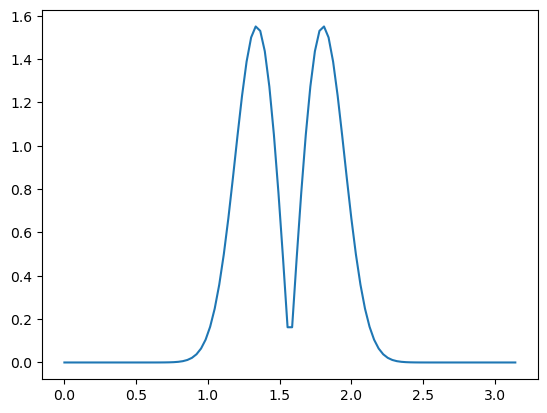

In [3]:
alpha = np.linspace(0, np.pi, 100)
plt.plot(alpha, rho(alpha))

Before for flare distribution we had the relation
$$
\cos \alpha = \sin \tau \sin \theta \cos \phi +\cos \theta \cos \tau  $$
and $\mu = \cos \theta$

Now we work with different variables but they are similar as follows $\beta \sim \alpha, \theta \sim \tau, \theta'\sim \theta$ and $ \phi'\sim \phi$ so  
$$
\cos \beta = \sin \theta \sin \theta' \cos \phi' +\cos \theta' \cos \theta  $$



The distribution for CME angle is assumed to be gaussion around 0 in the angle with the zenit. 

0.4946944833802725
1.0


Text(0, 0.5, "distribution of CMEs at angle $\\theta'$ with the zenit")

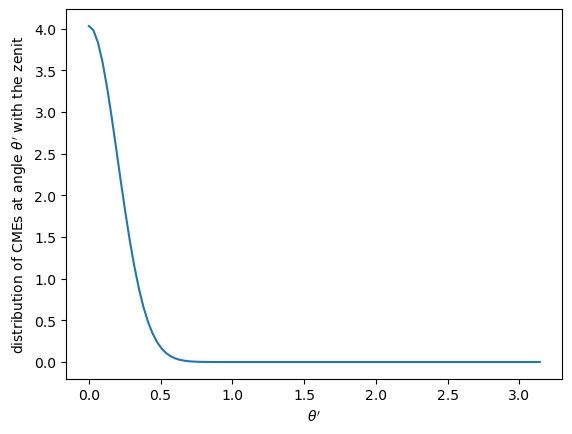

In [4]:
from scipy.stats import norm
# normalization, later to be determined
N = 1

def rho_CME(theta2, loc=0, scale = 0.2):
    return norm.pdf(theta2, loc, scale) /N

f = lambda theta2 : rho_CME(theta2) * np.sin(theta2) * 2 * np.pi


N = quad(f, 0, np.pi/2)[0]
print(N)
print(quad(f, 0, np.pi/2)[0])

T = np.linspace(0, np.pi, 100)
plt.plot(T, rho_CME(T))
plt.xlabel("$\\theta'$")
plt.ylabel("distribution of CMEs at angle $\\theta'$ with the zenit")



# Calculation of distribution of CMEs in viewing angle $\beta$ for given $\tau$.

Now we calculate the distribution in viewing angle $\beta$ for a given orientation angle $\tau$. 
This is a numerically exhausting procedure. 
We have a fast (monte carlo) and a slow approach (scipy.integrate.nquad) however it in both options struggles to get sufficient datapoints with good accuracy.

Later we will calculate the distribution of CMEs in viewing angle $\beta$ for average $\tau$ which can be analytically simplified and quickly solved.

In [5]:
def get_sinphi2(theta, phi, theta2, beta):
    cosphi2 = (np.cos(beta)  - np.cos(theta)*np.cos(theta2) )/ (np.sin(theta)*np.sin(theta2)) 
    return 0 if np.abs(cosphi2) >1 else (1-cosphi2**2)**0.5

def get_alpha(tau, theta, phi):
    return np.arccos( np.sin( tau ) * np.sin(theta) * np.cos(phi) + np.cos(tau) * np.cos(theta))



def f_integrand_(beta, tau, vec=True):
    if vec:
        def integrand_vec(x):
            theta = x[0]
            phi = x[1]
            theta2 = x[2]
            return integrand(theta, phi, theta2, beta, tau)
        return integrand_vec
    else:
        def integrand2(theta, phi, theta2):
            return integrand(theta, phi, theta2, beta, tau)
        return integrand2

def integrand(theta, phi, theta2, beta, tau, eps=1e-6):
    # corrected: sin(phi') in the denominator (was the numerator), see the markdown above.
    # sin(theta), sin(theta2) cancel against the sin(theta) d(theta), sin(theta2) d(theta2)
    # measure factors already applied outside this function, so they don't appear here at all.
    sinphi2 = get_sinphi2(theta, phi, theta2, beta)
    alpha = get_alpha(tau, theta, phi)
    return np.where(beta < theta - theta2, 0, np.where(beta > theta + theta2, 0,
            rho(alpha) * rho_CME(theta2) / (sinphi2 + eps)
                                                ))

\begin{equation}
    \rho_\beta(\beta) = \frac{1}{N} \int_{[0,\pi] \times [0,2\pi] \times [0,\pi] \times [0,2\pi ]}d\theta d\phi d\theta' d\phi' \sin\theta   
    \rho (\alpha(\theta, \phi)) \sin\theta'  \rho^{CME}(\theta') \delta(\beta -\arccos ( \sin \theta \sin \theta' \cos \phi' +\cos \theta' \cos \theta))
\end{equation}

so we use $\cos \beta = \sin \theta \sin \theta' \cos \phi' +\cos \theta' \cos \theta$, or equivalently that
$\cos \phi' = \frac{\cos\beta - \cos\theta'\cos\theta}{\sin \theta'\sin\theta}$
to find that, using $\delta(h(\phi')) = \sum_i \delta(\phi'-\phi'_i)/|h'(\phi'_i)|$ with
$h(\phi')=\beta-\arccos(f(\phi'))$: differentiating via the chain rule
($\frac{d}{dx}\arccos(x) = -1/\sqrt{1-x^2}$, and $\sqrt{1-f(\phi'_0)^2}=|\sin\beta|$ at the root) gives
$|h'(\phi'_0)| = \sin\theta\sin\theta'|\sin\phi'_0|/|\sin\beta|$. There are two roots in $[0,2\pi)$,
$\phi'_0$ and $2\pi-\phi'_0$ (since $\cos\phi'$ is even), both with the same $|h'|$, and nothing else in
the integral depends on $\phi'$, so they contribute equally:

\begin{equation}
    \int d\phi'   \delta(\beta -\arccos ( \sin \theta \sin \theta' \cos \phi' +\cos \theta' \cos \theta)) = \frac{2\,|\sin\beta|}{\sin\theta\sin\theta'\,|\sin\phi'(\theta, \theta',\beta)|}
\end{equation}

Therefore, since the $\sin\theta\sin\theta'$ from the measure cancels against the $\sin\theta\sin\theta'$
in the denominator above,
\begin{equation}
    \rho_\beta(\beta) = \frac{2}{N} \int_{[0,\pi] \times [0,2\pi] \times [0,\pi] }d\theta d\phi d\theta'   
    \rho (\alpha(\theta, \phi))   \rho^{CME}(\theta')  \frac{|\sin\beta|}{|\sin\phi'(\theta, \theta',\beta)|}
\end{equation}


This calculation will take a while — and with the corrected $1/\sin\phi'$ integrand it is *much* worse
for `nquad` specifically, since (unlike the old $\sin\phi'$-in-the-numerator form, which smoothly
vanishes at the edge of the valid region) the corrected integrand has a genuine, if integrable,
singularity right at that edge. A single `nquad` evaluation that used to take ~45s can now exceed two
minutes. We keep `get_rho_beta`/`nquad` below for reference, but switch to the vectorised Monte Carlo
estimator for all the actual
calculations further down.

# intergral numerical

In [6]:
import time
# import mcint
import random
import math
from scipy.integrate import nquad
from scipy.stats import qmc

# epsabs=1e-10, epsrel=1e-10,

def sampler():
    while True:
        theta     = random.uniform(0, np.pi)
        phi  = random.uniform(0, 2*np.pi)
        theta2    = random.uniform(0, np.pi/2)
    
        yield (theta, phi, theta2)

def get_rho_beta(beta, tau):
    # kept for reference; impractically slow for real use now (see markdown above) -
    # rho_betas below uses the vectorised Monte Carlo estimator mc_rho_betas instead.
    start_time = time.time()
    print(beta, tau, end='\r')
    result, error = nquad(f_integrand_(beta, tau, vec=False), [[0, np.pi],       # theta, phi, theta2
                                                [0, 2*np.pi],         # phi
                                                [0, np.pi / 2 ]], opts={"epsrel":0.05, 'epsabs':1e-2})       # theta2
    end_time = time.time()
    # corrected: multiply by |sin(beta)| (was dividing by it), see the markdown above.
    print(f'For params {beta=}, {tau = } we find the distibution to be {result * np.abs(np.sin(beta))}, with estimated error {error * np.abs(np.sin(beta))}. \
        Taking {(end_time-start_time):.2f} to calculate.')

    return result * np.abs(np.sin(beta))


def mc_rho_betas(betas, tau, m=23, seed=0):
    """Vectorised Monte Carlo estimate of rho_beta(beta, tau) for every beta at once.
    See the markdown above: with the corrected 1/sin(phi') integrand, nquad becomes
    impractically slow (a genuine, if integrable, singularity at the domain boundary),
    so this is used instead of get_rho_beta for everything below.

    Uses a scrambled Sobol' (quasi-random, low-discrepancy) sequence rather than plain
    pseudo-random sampling: since the same finite sample set is reused to evaluate every
    beta cut-point, plain Monte Carlo noise is correlated across beta (the same sample
    over/under-covers the same regions for every beta), which shows up as smooth spurious
    "wobble" in the resulting curve rather than independent point-to-point scatter. Sobol'
    sampling covers the (theta, phi, theta2) box far more evenly, which directly reduces
    that correlated wobble (~2-3x lower noise than pseudo-random at the same sample count,
    measured by comparing independent seeds). m=23 means 2**23 (~8.4M) samples.
    """
    sampler_ = qmc.Sobol(d=3, scramble=True, seed=seed)
    u = sampler_.random_base2(m=m)
    theta = (u[:, 0] * np.pi)[:, None]
    phi = (u[:, 1] * 2 * np.pi)[:, None]
    theta2 = (u[:, 2] * np.pi / 2)[:, None]
    betas_ = np.asarray(betas)[None, :]

    alpha = get_alpha(tau, theta, phi)
    denom = np.sin(theta) * np.sin(theta2)
    cosphi2 = (np.cos(betas_) - np.cos(theta) * np.cos(theta2)) / denom
    valid = np.abs(cosphi2) <= 1
    sinphi2 = np.where(valid, np.sqrt(np.clip(1 - cosphi2**2, 0, None)), 0.0)
    mask = (betas_ >= theta - theta2) & (betas_ <= theta + theta2) & (sinphi2 > 1e-6)
    safe_sinphi2 = np.where(mask, sinphi2, 1.0)

    integrand_ = np.where(mask, rho(alpha) * rho_CME(theta2) / safe_sinphi2, 0.0)
    volume = np.pi * (2 * np.pi) * (np.pi / 2)
    mean_val = integrand_.mean(axis=0) * volume
    return mean_val * np.abs(np.sin(betas_.ravel())) / 2


def rho_betas(betas, tau):
    return mc_rho_betas(betas, tau)

betas = np.linspace(0,np.pi/2, 20)
Taus =  np.linspace(0,np.pi/2, 5)

x = np.linspace(0,np.pi, 300)

# for tau :
#     a = rho_betas(betas, tau, fast)
#     plt.plot(betas, a, label=fr'$\tau=${round(tau*180/np.pi)}°')
#     print(betas, a)

def run_taus(T):
    dens = []
    for tau in T:
        print(f"calculating tau = {tau}")
        dens.append(rho_betas(betas, tau))

    plt.plot(x, np.sin(x)/2, "--", color='black', label="mean")

    plt.legend()
    plt.title("Distribution of CMEs")
    plt.xticks(np.linspace(0,np.pi, 4), range(0,181,60))
    plt.xlabel(r"$\beta$ [°]")
    plt.ylabel(r"density []")
    plt.xlim(0,np.pi)
    plt.show()
    return np.array(dens)

# Sundist

In [7]:
from pathlib import Path

def get_or_create_data(name):
    filename = f'calculations/{name}.npy'
    file_path = Path(filename)

    
    if file_path.exists():
        print(f"File '{filename}' found.")
        data = np.load(filename)
    else:
        print(f"File '{filename}' not found. Creating new data...")
        # Replace this with your actual data generation logic
        data = run_taus(Taus)
        
        # Save the file so it exists next time
        np.save(filename, data)
        print(f"Data saved to '{filename}'.")
        
    return data

dens = get_or_create_data("sundist")


File 'calculations/sundist.npy' found.


0.0 (6.283185307179588, 3.0015527959165525e-13)


0.39269908169872414 (6.283185269725044, 6.084386019439129e-08)


0.7853981633974483 (6.283185295494925, 2.4191430340664958e-08)


1.1780972450961724 (6.28318529055332, 3.749815596129032e-08)


1.5707963267948966 (6.283185307180058, 3.77118700711776e-08)


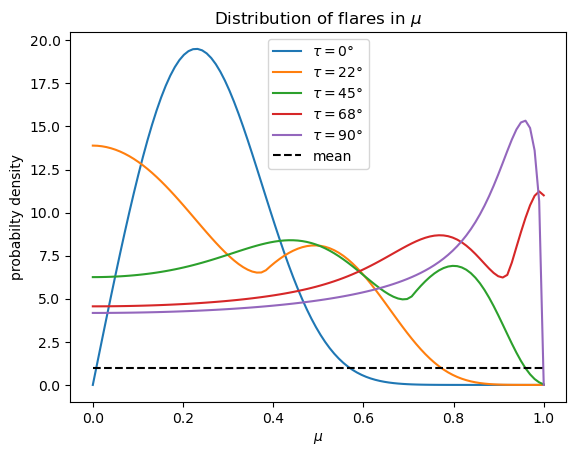

File 'calculations/sundist.npy' found.


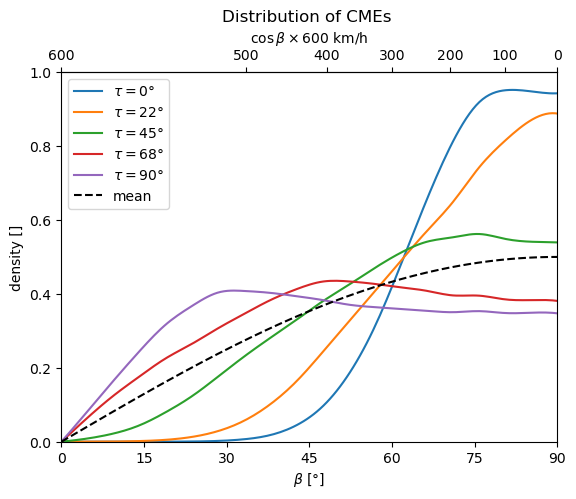

In [8]:
def speed2beta(v):
    return np.arccos(v / 600 )

def beta2speed(beta):
    return  np.cos(beta) * 600

from scipy.interpolate import make_interp_spline

def Flare_dist():

    def rho_mu(mu, tau):
        theta = np.arccos(mu)
        I = lambda phi: rho(get_alpha(tau, theta, phi))
        return 2 * quad(I, 0, 2*np.pi)[0]

    def rho_mus(mus, tau):
        return [ rho_mu(mu,tau) for mu in mus]

    rho_mu_of_tau = lambda tau : lambda mu : rho_mu(mu, tau)

    # def rho_mus2(mus, tau):
    #     return [ rho_mu(mu,tau) * (1-mu**2)**0.5 for mu in mus]

    mu = np.linspace(0,1, 100)

    for tau in np.linspace(0,np.pi/2, 5):
        plt.plot(mu, rho_mus(mu, tau), label=fr'$\tau=${round(tau*180/np.pi)}°')
        print(tau, quad(rho_mu_of_tau(tau), 0, 1))
    
    plt.plot(mu, mu*0+1, "--", color="black", label="mean")

    # plt.ylim(0,5)
    plt.title(r"Distribution of flares in $\mu$")
    plt.xlabel(r"$\mu$")
    plt.ylabel("probabilty density")
    plt.legend()
    plt.show()

Flare_dist()
T = np.linspace(0, np.pi/2, 5)
dens = get_or_create_data("sundist")

def plotting_(dens, taus):
    for i,d in enumerate(dens):
        smooth_curve = make_interp_spline(betas, d/(np.average(d) * np.pi))(x)
        plt.plot(x, smooth_curve, label=fr"$\tau=${round(taus[i]/np.pi*180)}°")
    plt.plot(x, np.sin(x)/2, "--", color='black', label="mean")

    plt.legend()
    plt.title("Distribution of CMEs ")
    plt.xticks(np.linspace(0,np.pi/2, 7), range(0,91,15))
    ax = plt.gca()
    secax = ax.secondary_xaxis('top', functions=(beta2speed, speed2beta))
    secax.set_xlabel(r'$\cos \beta \times 600$ km/h ')
    plt.xlabel(r"$\beta$ [°]")
    plt.ylabel(r"density []")
    plt.xlim(0,np.pi/2)
    plt.ylim(0,1)
    plt.show()

plotting_(dens, Taus)

C:\Users\mdewilde\AppData\Local\Temp\ipykernel_16596\2479919792.py:65: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(d, betas)
C:\Users\mdewilde\AppData\Local\Temp\ipykernel_16596\2479919792.py:92: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(d, betas)


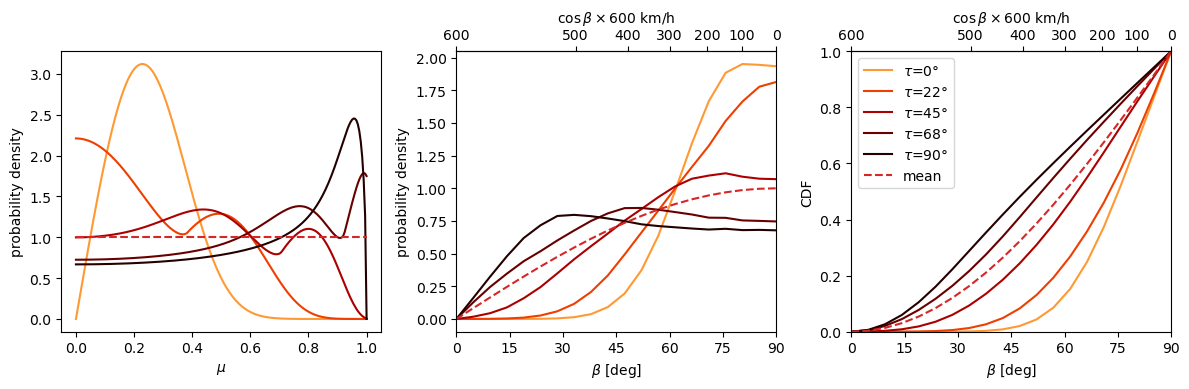

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from pathlib import Path

FIGURES_DIR = Path("Figures")
FIGURES_DIR.mkdir(exist_ok=True)

# --------------------------------------------------
# PHYSICS: define rho_mu at top level
# --------------------------------------------------
def rho_mu(mu, tau):
    theta = np.arccos(mu)
    I = lambda phi: rho(get_alpha(tau, theta, phi))
    return 2 * quad(I, 0, 2*np.pi)[0]


# --------------------------------------------------
# PLOTTING FUNCTION (1x3) — NORMALIZED CME PDFs
# --------------------------------------------------
def plot_flare_cme_pdf_cdf_3x1(
    taus,
    betas,
    dens_list,
    beta2speed=None,
    speed2beta=None,
    n_mu=200,
    mu_min=0.0,
    mu_max=1.0,
    name="dist",
    loc=0,
    cmap_name="brg",
):
    taus = np.asarray(taus, dtype=float)
    mu = np.linspace(mu_min, mu_max, int(n_mu))

    betas = np.asarray(betas, dtype=float)
    dens_list = np.asarray(dens_list, dtype=float)

    # --- colormap setup ---
    cmap = plt.get_cmap(cmap_name)
    colors = cmap(np.linspace(0.2, 0.9, len(taus)))

    fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharex=False)

    # ==================================================
    # (1) Flare PDF in μ
    # ==================================================
    ax = axs[0]
    for c, tau in zip(colors, taus):
        y = np.array([rho_mu(m, tau) for m in mu], dtype=float)
        ax.plot(mu, y / np.average(y), color=c, label=fr'$\tau$={int(round(tau*180/np.pi))}°')

    ax.plot(mu, np.ones_like(mu), "--", color="tab:red", label="mean")
    ax.set_xlabel(r"$\mu$")
    ax.set_ylabel("probability density")
    if loc == 0:
        ax.legend()

    # ==================================================
    # (2) CME PDF in β — NORMALIZED
    # ==================================================
    ax = axs[1]
    for c, d, tau in zip(colors, dens_list, taus):
        area = np.trapz(d, betas)
        d_pdf = d / area if area != 0 else d
        ax.plot(betas, d_pdf, color=c, label=fr'$\tau$={int(round(tau*180/np.pi))}°')

    # mean PDF (isotropic)
    ax.plot(betas, np.sin(betas), "--", color="tab:red", label="mean")

    ax.set_xlabel(r"$\beta$ [deg]")
    ax.set_ylabel("probability density")

    if (beta2speed is not None) and (speed2beta is not None):
        secax = ax.secondary_xaxis('top', functions=(beta2speed, speed2beta))
        secax.set_xlabel(r'$\cos \beta \times 600$ km/h')

    if betas.min() >= 0 and betas.max() <= np.pi/2 + 1e-6:
        ax.set_xticks(np.linspace(0, np.pi/2, 7))
        ax.set_xticklabels(range(0, 91, 15))
        ax.set_xlim(0, np.pi/2)

    if loc == 1:
        ax.legend()

    # ==================================================
    # (3) CME CDF in β (from normalized PDFs), scale 0 to 1
    # ==================================================
    ax = axs[2]
    for c, d, tau in zip(colors, dens_list, taus):
        area = np.trapz(d, betas)
        d_pdf = d / area if area != 0 else d

        cdf = np.cumsum((d_pdf[:-1] + d_pdf[1:]) * 0.5 * np.diff(betas))
        cdf = np.concatenate(([0.0], cdf))
        ax.plot(betas, cdf, color=c, label=fr'$\tau$={int(round(tau*180/np.pi))}°')

    # analytic mean CDF
    mean_cdf = 1.0 - np.cos(betas)
    ax.plot(betas, mean_cdf, "--", color="tab:red", label="mean")

    ax.set_xlabel(r"$\beta$ [deg]")
    ax.set_ylabel("CDF")
    ax.set_ylim(0, 1)

    if (beta2speed is not None) and (speed2beta is not None):
        secax = ax.secondary_xaxis('top', functions=(beta2speed, speed2beta))
        secax.set_xlabel(r'$\cos \beta \times 600$ km/h')

    if betas.min() >= 0 and betas.max() <= np.pi/2 + 1e-6:
        ax.set_xticks(np.linspace(0, np.pi/2, 7))
        ax.set_xticklabels(range(0, 91, 15))
        ax.set_xlim(0, np.pi/2)

    if loc == 2:
        ax.legend()

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"{name}.pdf")
    return fig, axs


# --------------------------------------------------
# USAGE
# --------------------------------------------------
fig, axs = plot_flare_cme_pdf_cdf_3x1(
    taus=Taus,
    betas=betas,
    dens_list=dens,
    beta2speed=beta2speed,
    speed2beta=speed2beta,
    name="dist1",
    loc=2,
    cmap_name="gist_heat_r",
)

plt.show()

# Polar flares

0.5000000000000001


Text(0, 0.5, 'probability density per unit area')

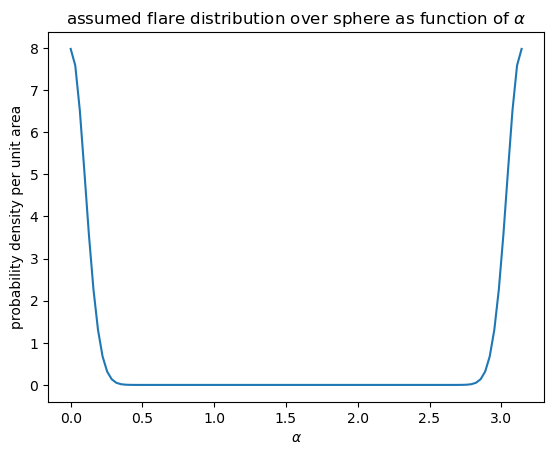

In [10]:
from scipy.stats import norm
# normalization, later to be determined

N = 1

def rho(alpha, loc=0, scale = 0.1):
    return (norm.pdf(alpha, loc, scale) + norm.pdf(alpha, loc+np.pi, scale)) /N

N = quad(lambda a :  rho(a), 0, np.pi/2)[0]
print(N)


alpha = np.linspace(0, np.pi, 100)
plt.plot(alpha, rho(alpha))
plt.title(r"assumed flare distribution over sphere as function of $\alpha$")
plt.xlabel(r"$\alpha$")
plt.ylabel('probability density per unit area')

In [11]:
# general distribution in mu for given tau
def get_alpha(tau, theta, phi):
    return np.arccos( np.sin( tau ) * np.sin(theta) * np.cos(phi) + np.cos(tau) * np.cos(theta))

    
def Flare_dist():

    def rho_mu(mu, tau):
        theta = np.arccos(mu)
        I = lambda phi: rho(get_alpha(tau, theta, phi))
        return 2 * quad(I, 0, 2*np.pi)[0]

    def rho_mus(mus, tau):
        return [ rho_mu(mu,tau) for mu in mus]

    rho_mu_of_tau = lambda tau : lambda mu : rho_mu(mu, tau)

    # def rho_mus2(mus, tau):
    #     return [ rho_mu(mu,tau) * (1-mu**2)**0.5 for mu in mus]

    mu = np.linspace(0,1, 100)

    for tau in np.linspace(0,np.pi/2, 5):
        plt.plot(mu, rho_mus(mu, tau), label=fr'$\tau=${round(tau*180/np.pi)}°')
        print(tau, quad(rho_mu_of_tau(tau), 0, 1))
    
    plt.plot(mu, mu*0+1, "--", color="black", label="mean")

    # plt.ylim(0,5)
    plt.title(r"Distribution of flares in $\mu$")
    plt.xlabel(r"$\mu$")
    plt.ylabel("probabilty density")
    plt.legend()
    plt.show()

0.0 (0.9993158136231646, 3.647190528409362e-12)


0.39269908169872414 (0.9993158136231631, 1.694194277505706e-13)


0.7853981633974483 (0.9993158136231668, 7.908570194260995e-11)


1.1780972450961724 (0.9993158136231668, 4.542747928977166e-09)


1.5707963267948966 (0.9993158136231646, 1.2719183056504428e-09)


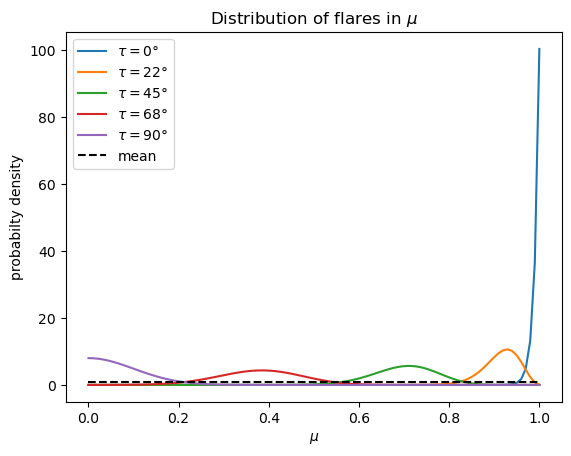

File 'calculations/polardist.npy' found.


In [12]:
Flare_dist()
T = np.linspace(0, np.pi/2, 5)
dens = get_or_create_data("polardist")


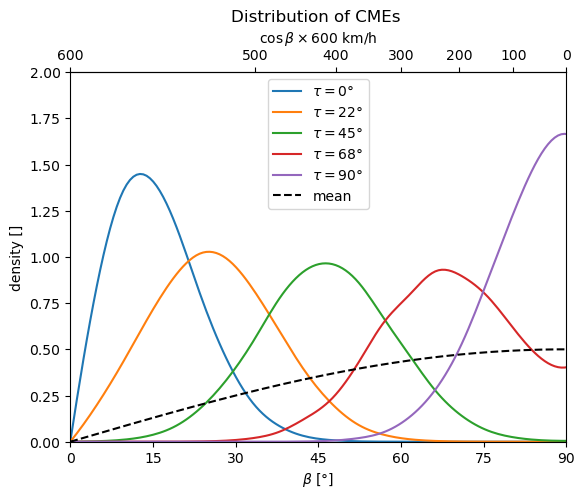

In [13]:
def speed2beta(v):
    return np.arccos(v / 600 )

def beta2speed(beta):
    return  np.cos(beta) * 600

from scipy.interpolate import make_interp_spline


def plotting_(dens, taus):
    for i,d in enumerate(dens):
        smooth_curve = make_interp_spline(betas, d/(np.average(d) * np.pi))(x)
        plt.plot(x, smooth_curve, label=fr"$\tau=${round(taus[i]/np.pi*180)}°")
    plt.plot(x, np.sin(x)/2, "--", color='black', label="mean")

    plt.legend()
    plt.title("Distribution of CMEs ")
    plt.xticks(np.linspace(0,np.pi/2, 7), range(0,91,15))
    ax = plt.gca()
    secax = ax.secondary_xaxis('top', functions=(beta2speed, speed2beta))
    secax.set_xlabel(r'$\cos \beta \times 600$ km/h ')
    plt.xlabel(r"$\beta$ [°]")
    plt.ylabel(r"density []")
    plt.xlim(0,np.pi/2)
    plt.ylim(0,2)
    plt.show()

plotting_(dens, Taus)



C:\Users\mdewilde\AppData\Local\Temp\ipykernel_16596\2479919792.py:65: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(d, betas)
C:\Users\mdewilde\AppData\Local\Temp\ipykernel_16596\2479919792.py:92: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(d, betas)


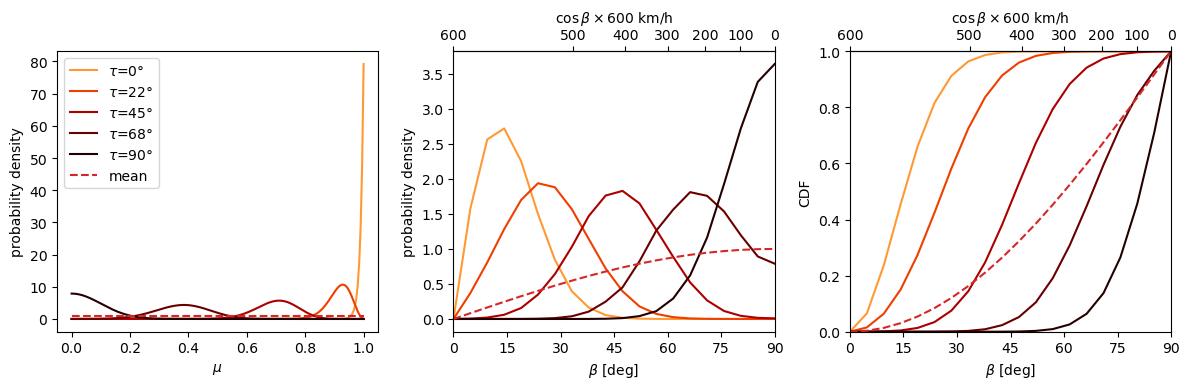

In [14]:
fig, axs = plot_flare_cme_pdf_cdf_3x1(
    taus=Taus,
    betas=betas,
    dens_list=dens,
    beta2speed=beta2speed,
    speed2beta=speed2beta,
    name="dist2",
    loc=0,
    cmap_name="gist_heat_r",
)

# flares around Equator (normal dist, no dip)

Text(0, 0.5, 'probability density per unit area')

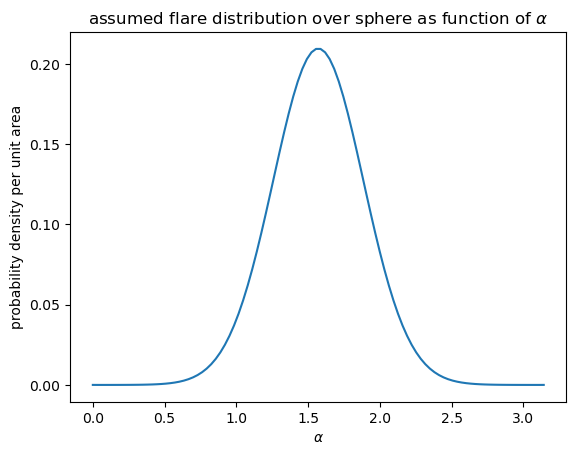

In [15]:
from scipy.stats import norm

def rho(alpha, loc=np.pi/2, scale = 0.3, err = 0.01):
    return norm.pdf(alpha, loc, scale) / 2 / np.pi / (np.sin(alpha) + err) 

alpha = np.linspace(0, np.pi, 100)
plt.plot(alpha, rho(alpha))
plt.title(r"assumed flare distribution over sphere as function of $\alpha$")
plt.xlabel(r"$\alpha$")
plt.ylabel('probability density per unit area')

0.0 (0.9895962000276162, 5.042964046353404e-09)


0.39269908169872414 (0.9895961988532547, 1.516983175045775e-09)


0.7853981633974483 (0.9895962002095553, 4.501296178332404e-09)


1.1780972450961724 (0.9895961876136867, 4.098245470594385e-09)


C:\Users\mdewilde\AppData\Local\Temp\ipykernel_16596\3779613015.py:11: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return 2 * quad(I, 0, 2*np.pi)[0]


1.5707963267948966 (0.989596200117882, 1.343628143600427e-11)


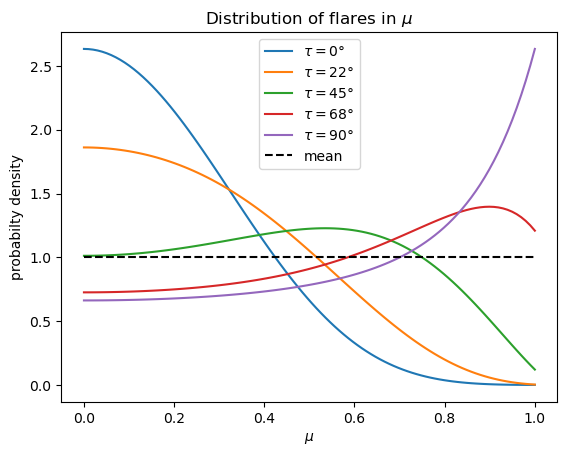

File 'calculations/equatornormaldist.npy' found.


In [16]:
Flare_dist()
T = np.linspace(0, np.pi/2, 5)
dens = get_or_create_data("equatornormaldist")


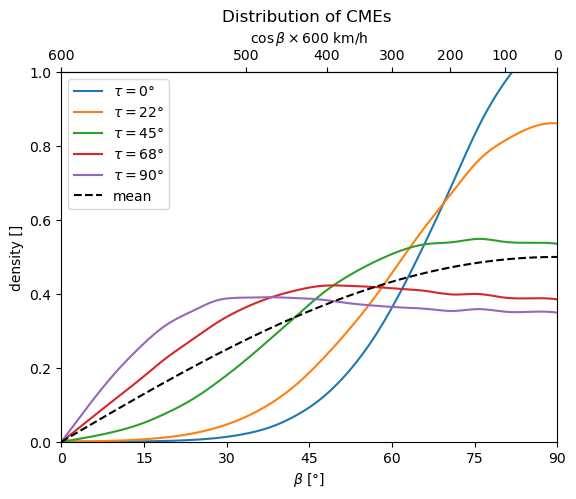

In [17]:
def speed2beta(v):
    return np.arccos(v / 600 )

def beta2speed(beta):
    return  np.cos(beta) * 600

from scipy.interpolate import make_interp_spline


def plotting_(dens, taus):
    for i,d in enumerate(dens):
        smooth_curve = make_interp_spline(betas, d/(np.average(d) * np.pi))(x)
        plt.plot(x, smooth_curve, label=fr"$\tau=${round(taus[i]/np.pi*180)}°")
    plt.plot(x, np.sin(x)/2, "--", color='black', label="mean")

    plt.legend()
    plt.title("Distribution of CMEs ")
    plt.xticks(np.linspace(0,np.pi/2, 7), range(0,91,15))
    ax = plt.gca()
    secax = ax.secondary_xaxis('top', functions=(beta2speed, speed2beta))
    secax.set_xlabel(r'$\cos \beta \times 600$ km/h ')
    plt.xlabel(r"$\beta$ [°]")
    plt.ylabel(r"density []")
    plt.xlim(0,np.pi/2)
    plt.ylim(0,1)
    plt.show()

plotting_(dens, Taus)



C:\Users\mdewilde\AppData\Local\Temp\ipykernel_16596\2479919792.py:65: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(d, betas)
C:\Users\mdewilde\AppData\Local\Temp\ipykernel_16596\2479919792.py:92: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(d, betas)


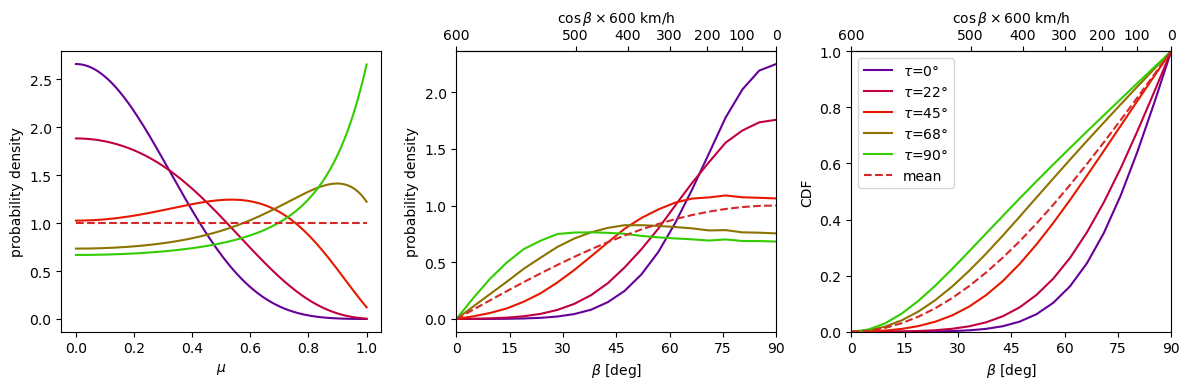

In [18]:
fig, axs = plot_flare_cme_pdf_cdf_3x1(
    taus=Taus,
    betas=betas,
    dens_list=dens,
    beta2speed=beta2speed,
    speed2beta=speed2beta,
    name="dist3",
    loc=2,
)

# Flares with stepfunction dist around equator

Text(0, 0.5, 'probability density per unit area')

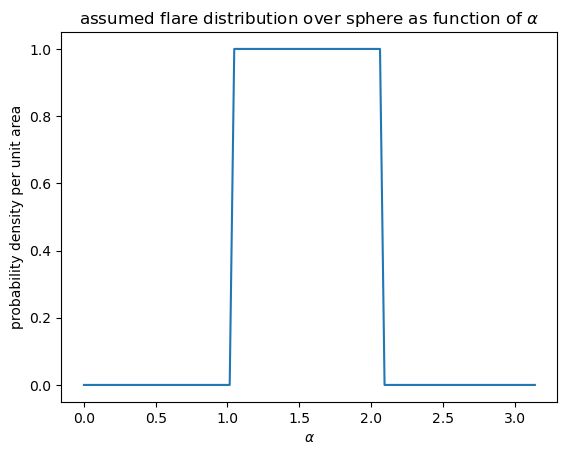

In [19]:
def rho(alpha, h=30/180*np.pi):
    return np.where(np.abs(alpha-np.pi/2) < h, 1, 0)


alpha = np.linspace(0, np.pi, 100)
plt.plot(alpha, rho(alpha))
plt.title(r"assumed flare distribution over sphere as function of $\alpha$")
plt.xlabel(r"$\alpha$")
plt.ylabel('probability density per unit area')

0.0 (6.283185307179586, 7.016609515630989e-14)


C:\Users\mdewilde\AppData\Local\Temp\ipykernel_16596\3779613015.py:11: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return 2 * quad(I, 0, 2*np.pi)[0]


C:\Users\mdewilde\AppData\Local\Temp\ipykernel_16596\3779613015.py:25: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  print(tau, quad(rho_mu_of_tau(tau), 0, 1))


0.39269908169872414 (6.283113268699922, 0.00014946526279637946)


0.7853981633974483 (6.28312602812515, 0.0024650655363972402)


1.1780972450961724 (6.282690892739802, 0.004444124139602046)


1.5707963267948966 (6.282738477965319, 0.002846612186670868)


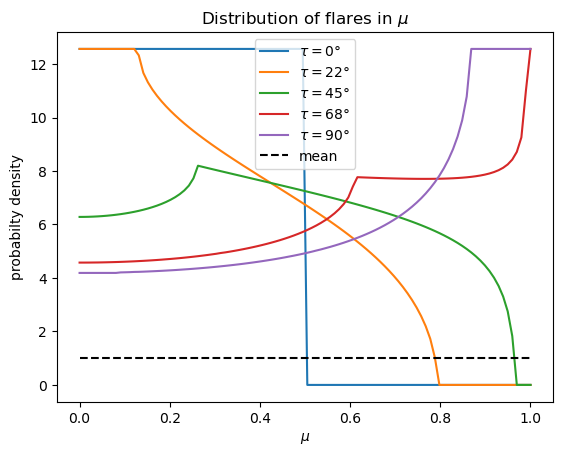

File 'calculations/blockdist.npy' found.


In [20]:
Flare_dist()
T = np.linspace(0, np.pi/2, 5)
dens = get_or_create_data("blockdist")


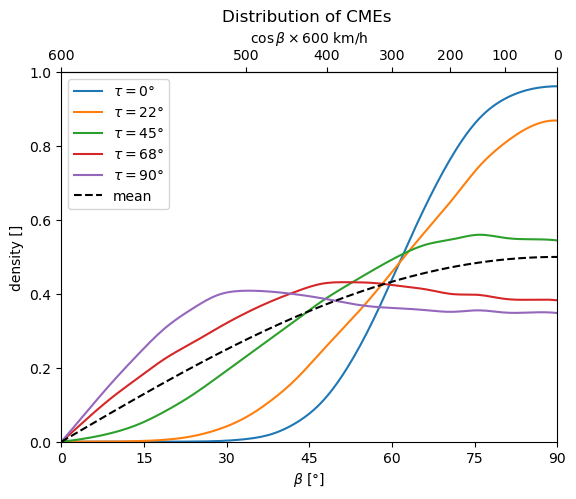

In [21]:
def speed2beta(v):
    return np.arccos(v / 600 )

def beta2speed(beta):
    return  np.cos(beta) * 600

from scipy.interpolate import make_interp_spline


def plotting_(dens, taus):
    for i,d in enumerate(dens):
        smooth_curve = make_interp_spline(betas, d/(np.average(d) * np.pi))(x)
        plt.plot(x, smooth_curve, label=fr"$\tau=${round(taus[i]/np.pi*180)}°")
    plt.plot(x, np.sin(x)/2, "--", color='black', label="mean")

    plt.legend()
    plt.title("Distribution of CMEs ")
    plt.xticks(np.linspace(0,np.pi/2, 7), range(0,91,15))
    ax = plt.gca()
    secax = ax.secondary_xaxis('top', functions=(beta2speed, speed2beta))
    secax.set_xlabel(r'$\cos \beta \times 600$ km/h ')
    plt.xlabel(r"$\beta$ [°]")
    plt.ylabel(r"density []")
    plt.xlim(0,np.pi/2)
    plt.ylim(0,1)
    plt.show()

plotting_(dens, Taus)



C:\Users\mdewilde\AppData\Local\Temp\ipykernel_16596\2479919792.py:15: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return 2 * quad(I, 0, 2*np.pi)[0]


C:\Users\mdewilde\AppData\Local\Temp\ipykernel_16596\2479919792.py:65: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(d, betas)
C:\Users\mdewilde\AppData\Local\Temp\ipykernel_16596\2479919792.py:92: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(d, betas)


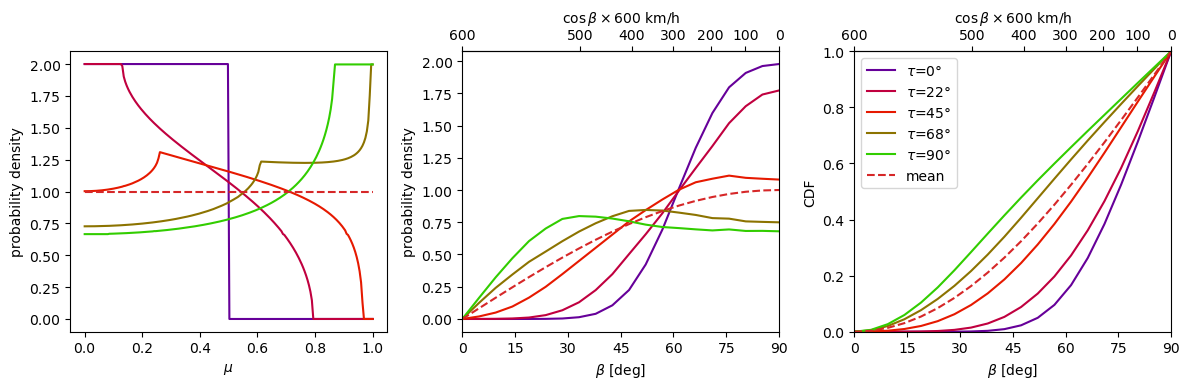

In [22]:
fig, axs = plot_flare_cme_pdf_cdf_3x1(
    taus=Taus,
    betas=betas,
    dens_list=dens,
    beta2speed=beta2speed,
    speed2beta=speed2beta,
    name="dist4",
    loc=2,
)

C:\Users\mdewilde\AppData\Local\Temp\ipykernel_16596\2479919792.py:15: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return 2 * quad(I, 0, 2*np.pi)[0]


C:\Users\mdewilde\AppData\Local\Temp\ipykernel_16596\2479919792.py:65: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(d, betas)
C:\Users\mdewilde\AppData\Local\Temp\ipykernel_16596\2479919792.py:92: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(d, betas)


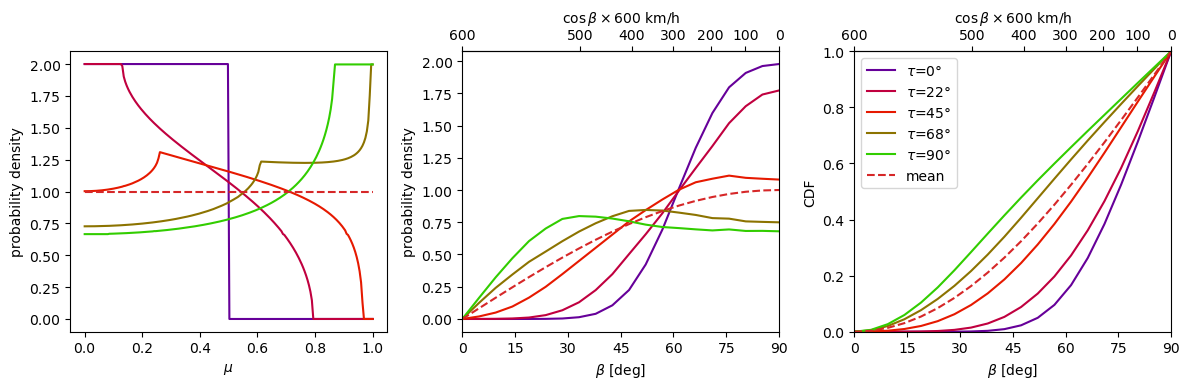

In [23]:
fig, axs = plot_flare_cme_pdf_cdf_3x1(
    taus=Taus,
    betas=betas,
    dens_list=dens,
    beta2speed=beta2speed,
    speed2beta=speed2beta,
    name="dist4",
    loc=2,
)

# Combined figure: solar-like vs. polar, PDF and CDF in $\beta$

Paper-style combined figure (2x2: PDF/CDF columns, solar-like/polar rows), adapted from the plotting
code that produced this figure in the manuscript. It reuses the corrected, already-cached
$\rho_\beta(\beta)$ densities computed above (`sundist.npy`, `polardist.npy` — same corrected
formula and Sobol' estimator as `mc_rho_betas` earlier in this notebook) rather than recomputing with
a separate estimator.

File 'calculations/sundist.npy' found.
File 'calculations/polardist.npy' found.


C:\Users\mdewilde\AppData\Local\Temp\ipykernel_16596\906092608.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pdf_solar = np.array([d / np.trapz(d, betas) for d in dens_solar])
C:\Users\mdewilde\AppData\Local\Temp\ipykernel_16596\906092608.py:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pdf_polar = np.array([d / np.trapz(d, betas) for d in dens_polar])


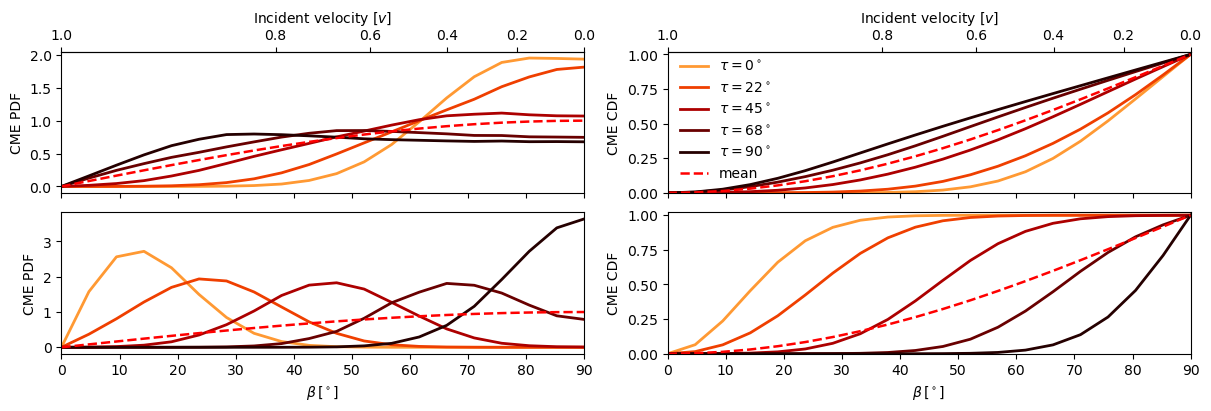

In [24]:
dens_solar = get_or_create_data("sundist")
dens_polar = get_or_create_data("polardist")

beta_deg = np.degrees(betas)


def cdf_from_pdf(x, pdf):
    dx = np.diff(x)
    mid = 0.5 * (pdf[1:] + pdf[:-1])
    cdf = np.concatenate([[0.0], np.cumsum(mid * dx)])
    return cdf / cdf[-1] if cdf[-1] != 0 else cdf


pdf_solar = np.array([d / np.trapz(d, betas) for d in dens_solar])
pdf_polar = np.array([d / np.trapz(d, betas) for d in dens_polar])
cdf_solar = np.array([cdf_from_pdf(betas, p) for p in pdf_solar])
cdf_polar = np.array([cdf_from_pdf(betas, p) for p in pdf_polar])

pdf_mean_ref = np.sin(betas)
cdf_mean_ref = 1.0 - np.cos(betas)

cmap = plt.get_cmap("gist_heat_r")
colors = [cmap(c) for c in np.linspace(0.2, 0.9, len(Taus))]

V_MAX = 1.0  # dimensionless incident-velocity units [v]


def beta_deg_to_vel(beta_deg_):
    return V_MAX * np.cos(np.radians(beta_deg_))


def vel_to_beta_deg(v):
    return np.degrees(np.arccos(np.clip(v, -V_MAX, V_MAX) / V_MAX))


fig, axes = plt.subplots(2, 2, figsize=(12, 4), sharex=True, constrained_layout=True)
for i, tau in enumerate(Taus):
    col = colors[i]
    lab = fr"$\tau={int(round(tau*180/np.pi))}^\circ$"
    axes[0, 0].plot(beta_deg, pdf_solar[i], lw=2, color=col)
    axes[0, 1].plot(beta_deg, cdf_solar[i], lw=2, color=col, label=lab)
    axes[1, 0].plot(beta_deg, pdf_polar[i], lw=2, color=col)
    axes[1, 1].plot(beta_deg, cdf_polar[i], lw=2, color=col)

axes[0, 0].plot(beta_deg, pdf_mean_ref, "--", color="red", lw=1.8)
axes[1, 0].plot(beta_deg, pdf_mean_ref, "--", color="red", lw=1.8)
axes[0, 1].plot(beta_deg, cdf_mean_ref, "--", color="red", lw=1.8, label="mean")
axes[1, 1].plot(beta_deg, cdf_mean_ref, "--", color="red", lw=1.8)

axes[0, 0].set_ylabel("CME PDF")
axes[1, 0].set_ylabel("CME PDF")
axes[0, 1].set_ylabel("CME CDF")
axes[1, 1].set_ylabel("CME CDF")
axes[1, 0].set_xlabel(r"$\beta\,[^\circ]$")
axes[1, 1].set_xlabel(r"$\beta\,[^\circ]$")

for ax in axes[:, 1]:
    ax.set_ylim(0.0, 1.02)
for ax in axes.ravel():
    ax.set_xlim(0.0, 90.0)

for ax in axes[0, :]:
    secax = ax.secondary_xaxis("top", functions=(beta_deg_to_vel, vel_to_beta_deg))
    secax.set_xlabel(r"Incident velocity [$v$]")

axes[0, 1].legend(frameon=False)

plt.savefig(FIGURES_DIR / "CME_dist_beta_solar_vs_polar.pdf")
plt.show()
